In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import matplotlib.pyplot as plt

In [ ]:
# Vocabulary size
max_features = 10000
max_len = 200

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=max_features)

# Pad sequences
x_train = sequence.pad_sequences(x_train, maxlen=max_len)
x_test = sequence.pad_sequences(x_test, maxlen=max_len)

print("Train shape:", x_train.shape)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train shape: (25000, 200)


In [ ]:
def build_rnn():
    model = Sequential([
        Embedding(max_features, 32, input_length=max_len),
        SimpleRNN(32),
        Dense(1, activation='sigmoid')
    ])
    return model

In [ ]:
def build_lstm():
    model = Sequential([
        Embedding(max_features, 32, input_length=max_len),
        LSTM(32),
        Dense(1, activation='sigmoid')
    ])
    return model

In [ ]:
def build_gru():
    model = Sequential([
        Embedding(max_features, 32, input_length=max_len),
        GRU(32),
        Dense(1, activation='sigmoid')
    ])
    return model

In [ ]:
def compile_model(model):
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

In [ ]:
epochs = 5
batch_size = 64

# RNN
rnn_model = compile_model(build_rnn())
history_rnn = rnn_model.fit(x_train, y_train,
                            epochs=epochs,
                            batch_size=batch_size,
                            validation_data=(x_test, y_test))

# LSTM
lstm_model = compile_model(build_lstm())
history_lstm = lstm_model.fit(x_train, y_train,
                              epochs=epochs,
                              batch_size=batch_size,
                              validation_data=(x_test, y_test))

# GRU
gru_model = compile_model(build_gru())
history_gru = gru_model.fit(x_train, y_train,
                            epochs=epochs,
                            batch_size=batch_size,
                            validation_data=(x_test, y_test))

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


391/391 ━━━━━━━━━━━━━━━━━━━━ 27s 62ms/step - accuracy: 0.7103 - loss: 0.5283 - val_accuracy: 0.8404 - val_loss: 0.3732
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 46s 75ms/step - accuracy: 0.8674 - loss: 0.3247 - val_accuracy: 0.8465 - val_loss: 0.3517
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 25s 64ms/step - accuracy: 0.9048 - loss: 0.2460 - val_accuracy: 0.8506 - val_loss: 0.3680
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 29s 75ms/step - accuracy: 0.9287 - loss: 0.1887 - val_accuracy: 0.8223 - val_loss: 0.4180
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 37s 65ms/step - accuracy: 0.9032 - loss: 0.2409 - val_accuracy: 0.6840 - val_loss: 0.6348
Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 50s 121ms/step - accuracy: 0.8070 - loss: 0.4174 - val_accuracy: 0.8738 - val_loss: 0.3007
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 80s 116ms/step - accuracy: 0.9051 - loss: 0.2432 - val_accuracy: 0.8653 - val_loss: 0.3269
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 46s 117ms/step - accuracy: 0.9280 - loss: 0.1899 - val_accuracy: 0

In [ ]:
print("RNN Accuracy:", rnn_model.evaluate(x_test, y_test)[1])
print("LSTM Accuracy:", lstm_model.evaluate(x_test, y_test)[1])
print("GRU Accuracy:", gru_model.evaluate(x_test, y_test)[1])

782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.6840 - loss: 0.6348
RNN Accuracy: 0.6839600205421448
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.8577 - loss: 0.4409
LSTM Accuracy: 0.8576800227165222
691/782 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.8629 - loss: 0.3928

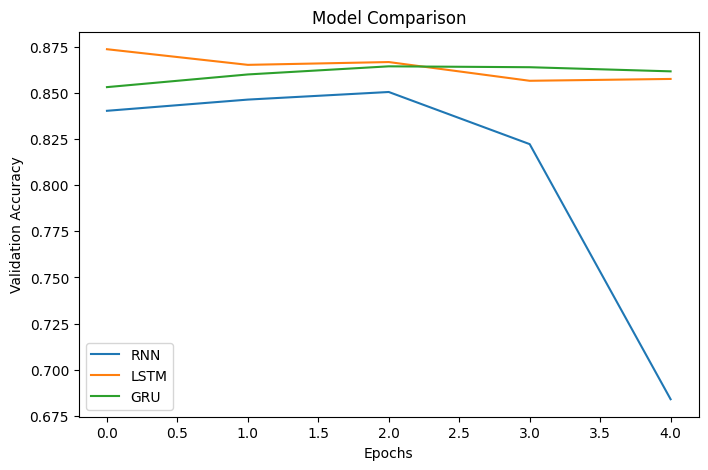

In [ ]:
def plot_history(history, label):
    plt.plot(history.history['val_accuracy'], label=label)

plt.figure(figsize=(8,5))
plot_history(history_rnn, "RNN")
plot_history(history_lstm, "LSTM")
plot_history(history_gru, "GRU")

plt.title("Model Comparison")
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()